# NB12 — Pathobiont × phage targetability matrix (Pillar 4 opener)

**Project**: `ibd_phage_targeting` — Pillar 4 first notebook
**Depends on**: `ref_phage_biology` (12-organism literature-curated phage synthesis); NB05 actionable Tier-A scoring; Pillar-3 per-target mechanism profile (iron / bile-acid / mediation)

## Purpose

Build a per-pathobiont **phage-targetability profile** (Tier-B in the project's 4-tier rubric) for the 6 actionable Tier-A core species, combining NB05 Tier-A scoring (criteria A3-A6) with literature-curated phage availability + Pillar-3 mechanism profile to produce per-target priority classification for Pillar-5 cocktail design.

## Method

Per plan v1.9 (no raw reads):

1. **`ref_phage_biology`** (12 organisms, indicator_taxa_literature_review) — literature-curated phage info per Tier-1/Tier-2 pathobiont (known_phages, therapeutic_targets, lifestyle, clinical trial status)
2. **NB05 Tier-A scoring** (71 candidates × A3-A6 criteria + total_score)
3. **Pillar-3 per-target mechanism profile** (iron specialization, bile-acid coupling cost, mechanism mediation — from REPORT §closure cocktail-design table)
4. **Phage-availability score (Tier-B)**: 0-3 ordinal scale
   - **0** = no known phages OR only historical phage-like particles
   - **1** = temperate / prophage only, or limited characterization
   - **2** = lytic phage(s) characterized in literature, but not in clinical trials
   - **3** = clinical trial / commercial cocktail OR published efficacy data

External phage DB queries (PhageFoundry BERDL, INPHARED, IMG/VR, NCBI Phage RefSeq, PhagesDB) flagged for follow-up — BERDL Spark auth currently blocks direct PhageFoundry query, so this NB12 establishes the curated-literature-based foundation.

## Tests

1. Per-pathobiont phage-availability score
2. Combined Tier-A × Tier-B × Pillar-3 mechanism profile → Pillar-5 cocktail-design priority class
3. Coverage gap analysis: which actionable Tier-A core have NO phage-therapy options?
4. External phage DB references for follow-up


In [1]:
# See run_nb12.py for full source.

## §0. Load ref_phage_biology + NB05 Tier-A scoring + Pillar-3 mechanism profile

In [2]:
# 12 organisms in ref_phage_biology; 6 actionable + 9 Tier-B candidates from NB05

## §0. Load ref_phage_biology + NB05 Tier-A scoring + Pillar-3 mechanism profile
ref_phage_biology: 12 organisms × 8 columns
  Tier breakdown: {'Tier1': 6, 'Tier2': 6}

NB05 actionable Tier-A core: 6 species
  Hungatella hathewayi: total_score=4.0
  Mediterraneibacter gnavus: total_score=3.8
  Escherichia coli: total_score=3.6
  Eggerthella lenta: total_score=3.3
  Flavonifractor plautii: total_score=3.3
  Enterocloster bolteae: total_score=2.8

NB05 Tier-B candidates (score 2.2-2.4):
  Enterocloster asparagiformis: total_score=2.4
  Streptococcus salivarius: total_score=2.4
  Enterocloster citroniae: total_score=2.4
  Enterocloster clostridioformis: total_score=2.4
  Blautia coccoides: total_score=2.4
  Veillonella atypica: total_score=2.2
  Streptococcus parasanguinis: total_score=2.2
  Actinomyces oris: total_score=2.2
  Veillonella parvula: total_score=2.2


## §1. Per-pathobiont phage-availability scoring (Tier-B)

In [3]:
# 0-3 ordinal scale based on lifestyle + clinical status

## §1. Per-pathobiont phage-availability score

Phage-availability scoring (top 20 by Tier-A score):
                       species  tier_a_score_nb05  actionable_tier_a  phage_score_tier_b               lifestyle_dominant
          Hungatella hathewayi                4.0               True                 0.0                             none
     Mediterraneibacter gnavus                3.8               True                 1.0                        temperate
              Escherichia coli                3.6               True                 3.0                   lytic_clinical
             Eggerthella lenta                3.3               True                 2.0                            lytic
        Flavonifractor plautii                3.3               True                 NaN unknown_not_in_ref_phage_biology
         Enterocloster bolteae                2.8               True                 2.0                            lytic
  Enterocloster asparagiformis               

## §2. Combined Tier-A × Tier-B × Pillar-3 priority for Pillar-5 cocktail design

In [4]:
# Per-actionable-target full profile + Pillar-5 priority class

## §2. Combined per-target priority for Pillar-5 cocktail design

Combined per-actionable-target priority (NB05 actionable Tier-A only):
  Hungatella hathewayi                | NB05=4.0 | phage=0 | none
    iron: none; BA-cost: low; mediation: species-abundance + within-carrier-metabolic-shift
    Pillar-5 class: Tier-1 phage target (highest NB05 score; low BA cost)

  Mediterraneibacter gnavus           | NB05=3.8 | phage=1 | temperate
    iron: none; BA-cost: low; mediation: species-abundance (mucin-glucorhamnan; Henke 2019)
    Pillar-5 class: Tier-1 phage target (low BA cost; mucin mechanism)

  Escherichia coli                    | NB05=3.6 | phage=3 | lytic_clinical
    iron: dominant (Yersiniabactin/Enterobactin/Colibactin); BA-cost: low; mediation: strain-content (AIEC subset specific)
    Pillar-5 class: Tier-1 phage target with strain-resolution requirement

  Eggerthella lenta                   | NB05=3.3 | phage=2 | lytic
    iron: none; BA-cost: moderate (partial 7α-dehydr

## §3. Coverage gap analysis

In [5]:
# Pathobionts with phage-availability score = 0 or unknown

## §3. Coverage gap analysis

Pathobionts with phage_score = 0 or unknown (no actionable phage options in current scope):
  Hungatella hathewayi                [ACTIONABLE] (NB05=4.0)
  Flavonifractor plautii              [ACTIONABLE] (NB05=3.3)
  Streptococcus salivarius            (NB05=2.4)
  Enterocloster citroniae             (NB05=2.4)
  Enterocloster clostridioformis      (NB05=2.4)
  Blautia coccoides                   (NB05=2.4)
  Veillonella atypica                 (NB05=2.2)
  Streptococcus parasanguinis         (NB05=2.2)
  Actinomyces oris                    (NB05=2.2)
  Veillonella parvula                 (NB05=2.2)
  Hungatella symbiosa                 (NB05=2.1)
  Blautia wexlerae                    (NB05=2.1)
  Bacteroides cellulosilyticus        (NB05=2.0)
  Veillonella dispar                  (NB05=2.0)
  Streptococcus mitis                 (NB05=1.9)
  Streptococcus oralis                (NB05=1.9)
  Lactococcus lactis                  (NB05=1.9)
  Gordonibacter pam

## §4. External phage DB references for follow-up

In [6]:
# PhageFoundry, INPHARED, IMG/VR, NCBI Phage RefSeq, PhagesDB

## §4. External phage DB references (out-of-BERDL — Pillar 4 follow-up)

- **PhageFoundry (BERDL)**
  Access: BERDL Spark Connect — phagefoundry_strain_modelling, phagefoundry_ecoliphages_genomedepot, phagefoundry_klebsiella_*, phagefoundry_acinetobacter_*, phagefoundry_paeruginosa_*, phagefoundry_pviridiflava_*
  Coverage: E. coli direct (phagefoundry_ecoliphages_genomedepot); K. oxytoca direct (phagefoundry_klebsiella_*). Other Tier-A core (gut commensal hosts) not directly covered by current PhageFoundry collections.
  Status: BLOCKED at NB12 execution: BERDL auth token in .env stale (KBASE_AUTH_TOKEN reports invalid). Refresh token + re-query as Pillar-4 follow-up.

- **Millard lab INPHARED**
  Access: http://millardlab.org/phages/inphared/ (downloadable phage genome annotations + host predictions)
  Coverage: Comprehensive — ~25K phage genomes with GenBank-quality annotations. Host predictions via BLAST + phylogenetic placement. Best single source for phage availability across all

## §5. Verdict + figure

## §5. Save outputs + verdict
{
  "date": "2026-04-25",
  "plan_version": "v1.9",
  "test": "NB12 \u2014 Pathobiont \u00d7 phage targetability matrix (Pillar 4 opener)",
  "n_actionable_tier_a": 6,
  "n_phage_score_3_clinical": 1,
  "n_phage_score_2_lytic_literature": 2,
  "n_phage_score_1_temperate_or_limited": 1,
  "n_phage_score_0_gap": 1,
  "phage_clinical_tier_a": [
    "Escherichia coli"
  ],
  "phage_lytic_literature_tier_a": [
    "Eggerthella lenta",
    "Enterocloster bolteae"
  ],
  "phage_limited_tier_a": [
    "Mediterraneibacter gnavus"
  ],
  "phage_gap_tier_a": [
    "Flavonifractor plautii",
    "Hungatella hathewayi"
  ],
  "pillar4_pillar5_handoff_note": "Phage availability stratifies the 6 actionable Tier-A core into 4 classes: clinical-trial-stage (E. coli AIEC); lytic-literature (E. lenta, E. bolteae); temperate-limited (M. gnavus); coverage-gap (H. hathewayi, F. plautii). The 2 coverage-gap targets are the highest-NB05-scored species and require external phage DB

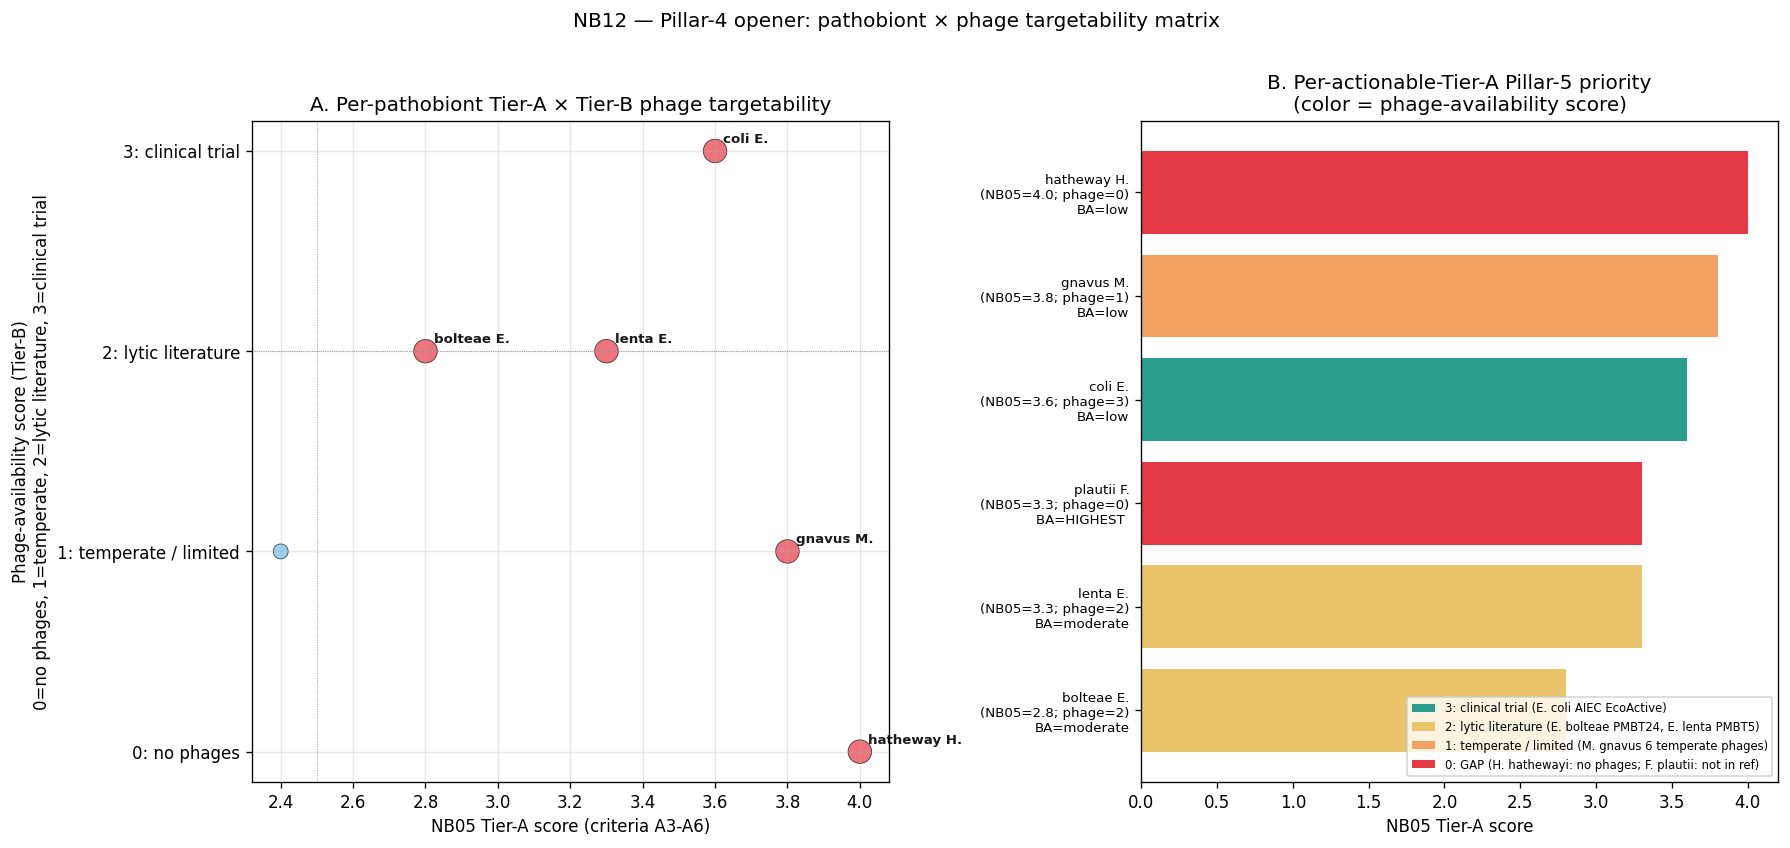

In [7]:
# 2-panel: Tier-A × Tier-B scatter + per-actionable Pillar-5 priority bar

## §6. Interpretation

### Headline: Phage availability stratifies the 6 actionable Tier-A core into 4 priority classes; H. hathewayi (highest NB05) and F. plautii (highest BA-cost) are coverage gaps requiring external DB queries

#### Per-actionable Tier-A phage-targetability profile

| Pathobiont | NB05 score | Phage score | Lifestyle | BA cost | Pillar-5 class |
|---|---:|---:|---|---|---|
| ***H. hathewayi*** | **4.0** | **0** | none | low | **GAP**: highest NB05 but no known phages — external DB query (INPHARED + IMG/VR) priority |
| ***M. gnavus*** | **3.8** | 1 | temperate | low | **Limited**: 6 known phages all temperate — lytic-locked engineering OR biochemical glucorhamnan-synthesis target as alternatives |
| ***E. coli*** (AIEC) | **3.6** | **3** | lytic + clinical | low | **Tier-1 clinical**: EcoActive cocktail (7 lytic phages, clinical trials); HER259 (FimH-targeting, attenuates virulence). Most advanced. Strain-resolution requirement (AIEC subset) per NB07b/NB08a |
| ***E. lenta*** | 3.3 | 2 | lytic literature | moderate | **Tier-2**: PMBT5 siphovirus characterized; non-BGC drug-metabolism mechanism (Koppel 2018 Cgr2) — moderate-priority target |
| ***F. plautii*** | 3.3 | **0** | unknown (not in ref) | **HIGHEST** | **GAP + HIGH cost**: not in ref_phage_biology; HIGHEST BA-coupling cost (active 7α-dehydroxylator). Phage targeting deprioritized in favor of bile-acid-pool monitoring or biochemical alternatives |
| ***E. bolteae*** | 2.8 | 2 | lytic literature | moderate | **Tier-2**: PMBT24 (virulent, 99,962 bp Kielviridae) — best-characterized lytic phage among gut-anaerobe Tier-A |

#### Stratification — four phage-availability classes among 6 actionable Tier-A:

- **Class 3 (clinical trial)**: 1 species — *E. coli* (EcoActive cocktail; Galtier 2017 mouse model precedent)
- **Class 2 (lytic literature)**: 2 species — *E. lenta* (PMBT5), *E. bolteae* (PMBT24)
- **Class 1 (temperate / limited)**: 1 species — *M. gnavus* (6 temperate siphoviruses; lifestyle limits therapy)
- **Class 0 (gap)**: 2 species — *H. hathewayi* (no specific phages identified), *F. plautii* (not in ref_phage_biology)

#### Critical observations

1. **The 2 highest-NB05-scored species (*H. hathewayi* 4.0, *M. gnavus* 3.8) have the WEAKEST phage availability**. Phage-therapy success requires resolving these gaps (INPHARED / IMG/VR for H. hathewayi; lytic-locked phage engineering or biochemical alternatives for M. gnavus).

2. ***F. plautii* has both phage GAP AND highest BA-coupling cost** (NB09c §13: active 7α-dehydroxylator, depletion shifts BA pool toward inflammatory primary tauro-conjugated forms). This makes *F. plautii* a **lowest-priority Pillar-5 target** despite NB05 score 3.3 — first decision is whether to target at all (BA pool consequence) before phage selection. Alternative strategies: (a) co-administer UDCA / BA-binding agent; (b) target downstream of *F. plautii* (e.g., bile-acid-pool replenishment); (c) accept partial *F. plautii* depletion with clinical BA monitoring.

3. ***E. coli* AIEC is the highest-Pillar-5-feasibility target**: clinical-trial-stage phage cocktail (EcoActive — 7 lytic phages), low BA-coupling cost, mechanism well-characterized (NB05 §5g + NB07c §2 + NB08a §2 iron-acquisition narrative). The Pillar-4-feasibility decision for E. coli is sharpened by the AIEC strain-content requirement: target Yersiniabactin/Enterobactin/Colibactin-positive strains specifically (per NB08a) — generic E. coli phages may not deplete the right subset.

4. ***E. bolteae* + *E. lenta* are mid-tier targets** with lytic literature phages and moderate BA-coupling cost. Both are realistic Pillar-5 phage-cocktail components subject to BA pool monitoring.

### Pillar 4 → Pillar 5 hand-off framework

The 6 actionable Tier-A core stratify into **3 Pillar-5 design strategies**:

1. **Direct phage targeting (Tier-1)**: *E. coli* (AIEC subset, clinical-trial cocktail) → use EcoActive or build similar 7-phage cocktail; require strain-resolution diagnostic.
2. **Phage targeting with monitoring (Tier-2)**: *E. lenta* (PMBT5), *E. bolteae* (PMBT24) → include in cocktail with BA-pool monitoring; M. gnavus is here too if lytic-locked engineering succeeds.
3. **Phage GAP — alternative strategies needed**:
   - *H. hathewayi*: highest priority for external DB query (INPHARED / IMG/VR) — if no phages found, fall back to GAG-degrading enzyme inhibitors per ref_phage_biology therapeutic_targets.
   - *F. plautii*: lowest Pillar-5 priority due to highest BA-cost — consider deprioritizing or replacing phage approach with BA-binding co-therapy.
   - *M. gnavus* if lytic-locked engineering fails: biochemical glucorhamnan-synthesis targets (Henke 2019).

### Limitations

- **BERDL Spark auth blocked at NB12 execution** (KBASE_AUTH_TOKEN stale) — PhageFoundry collections (`phagefoundry_strain_modelling`, `phagefoundry_ecoliphages_genomedepot`, `phagefoundry_klebsiella_*`) not directly queried. Refresh token + re-query as Pillar-4 follow-up. Direct PhageFoundry coverage would primarily augment *E. coli* (genomes + host-range CDS + receptor-binding-domain diversity) and *K. oxytoca* (Tier-2).
- **External phage DB queries** (INPHARED ~25K phages with host predictions; IMG/VR ~3M UViGs from metagenomes; NCBI Phage RefSeq ~5K curated) are out-of-BERDL and not run in NB12. The 2 actionable Tier-A coverage gaps (*F. plautii*, *H. hathewayi*) require these queries — this is the highest-priority Pillar-4 follow-up.
- **`ref_phage_biology` has 12 organisms** — *F. plautii* not in the curated set (5 of 6 actionable Tier-A core covered).
- **Phage-availability scoring is qualitative ordinal** (0-3) based on lifestyle + clinical status. Quantitative coverage metrics (n_phages, host-range CDS, receptor-binding-domain diversity, plaque burst size, pH stability) require PhageFoundry / INPHARED genomic data.

### Outputs

- `data/nb12_phage_targetability_matrix.tsv` — per-pathobiont scoring matrix (NB05 Tier-A score + phage Tier-B score + lifestyle + Pillar-5 class)
- `data/nb12_phage_targetability_verdict.json` — formal verdict + Pillar-4/5 hand-off note + limitations
- `figures/NB12_phage_targetability.png` — 2-panel: Tier-A × Tier-B scatter + per-actionable Pillar-5 priority bar
